In [1]:
import xgboost as xgb
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("XGBoost version:", xgb.__version__)

/home/theo/miniconda3/envs/energy/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


XGBoost version: 3.2.0


# Load Data

In [ ]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

import pandas as pd
import numpy as np
import xgboost as xgb
from helper import *
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------------------------------------
# 1. Load data
# ---------------------------------------------------------
set_seed(42)
merged_building_df = pd.read_csv('/home/theo/Desktop/CESI_DUTh/XAI_Energy_Consumption_Prediction/Data/merged_sud_with_power.csv')

metric_datasets = extract_metric_datasets(merged_building_df)
co2_df = metric_datasets.get('CO2 indoor')
humidity_df = metric_datasets.get('HUM indoor')
temp_df = metric_datasets.get('TMP indoor')

df = merged_building_df

In [ ]:
df.head()

,Date and Time,TMP indoor espacesalaries_s41,HUM indoor espacesalaries_s41,CO2 indoor espacesalaries_s41,VOCT indoor espacesalaries_s41,DBAA indoor espacesalaries_s41,DBAP indoor espacesalaries_s41,LIGHT_LUX indoor espacesalaries_s41,OCCUPANCY_RATE indoor espacesalaries_s41,TMP indoor b20,...,CO2 indoor t12,VOCT indoor t12,DBAA indoor t12,DBAP indoor t12,LIGHT_LUX indoor t12,OCCUPANCY_RATE indoor t12,Horodatage_Début,Valeur,Consommation,Horodatage_Fin
0,2026-03-01 00:00:00,17.2,55.0,461.0,16.0,36.0,39.0,0.0,0.0,17.2,...,521.0,16.0,37.0,45.0,0.0,0.0,2026-03-01 00:00:00,39.0,3.250000,2026-03-01 00:10:00
1,2026-03-01 00:10:00,17.2,54.0,452.0,20.0,36.0,39.0,0.0,0.0,17.2,...,529.0,20.0,36.0,40.0,0.0,0.0,2026-03-01 00:10:00,38.0,3.166667,2026-03-01 00:20:00
2,2026-03-01 00:20:00,17.2,54.0,442.0,32.0,37.0,40.0,0.0,0.0,17.2,...,518.0,21.0,38.0,49.0,0.0,0.0,2026-03-01 00:20:00,27.0,2.250000,2026-03-01 00:30:00
3,2026-03-01 00:30:00,17.2,54.0,446.0,28.0,37.0,46.0,0.0,0.0,17.2,...,519.0,19.0,37.0,44.0,0.0,0.0,2026-03-01 00:30:00,16.0,1.333333,2026-03-01 00:40:00
4,2026-03-01 00:40:00,17.1,54.0,453.0,20.0,36.0,42.0,0.0,0.0,NaN,...,507.0,29.0,37.0,45.0,0.0,0.0,2026-03-01 00:40:00,23.0,1.916667,2026-03-01 00:50:00


# Build flattened train/val/test arrays

In [ ]:
# ---------------------------------------------------------
# 2. Clean & scale
# ---------------------------------------------------------
cols_to_drop = ['Date and Time', 'Horodatage_Début', 'Horodatage_Fin', 'Valeur']
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

df_numeric = df.drop(columns=cols_to_drop)
df_numeric = df_numeric.ffill().bfill()

target_col_name = 'Consommation'
assert target_col_name in df_numeric.columns, f"'{target_col_name}' not found in dataframe columns!"
target_idx = df_numeric.columns.get_loc(target_col_name)

scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_numeric.values)
print(f"Transformed sequence shape: {data_scaled.shape}")

def inverse_transform_target(values_scaled, scaler, col_idx):
    mean = scaler.mean_[col_idx]
    scale = scaler.scale_[col_idx]
    return values_scaled * scale + mean

Transformed sequence shape: (9648, 221)


In [ ]:

# ---------------------------------------------------------
# 3. Build sliding windows: keep ONLY Consommation_t-0,
#    drop all other target lags.
# ---------------------------------------------------------
seq_length = 12
gap = seq_length

n_windows = len(data_scaled) - seq_length
split_point = int(n_windows * 0.8)

train_range = range(0, split_point - gap)
test_range = range(split_point, n_windows)

def build_window_row(i):
    window = data_scaled[i : i + seq_length, :]
    non_target = np.delete(window, target_idx, axis=1)
    consumption_t0 = window[-1, target_idx]
    return np.concatenate([non_target.flatten(), [consumption_t0]])

X_train, y_train = [], []
for i in train_range:
    X_train.append(build_window_row(i))
    y_train.append(data_scaled[i + seq_length, target_idx])

X_test, y_test = [], []
for i in test_range:
    X_test.append(build_window_row(i))
    y_test.append(data_scaled[i + seq_length, target_idx])

X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

base_feature_names = [c for c in df_numeric.columns.tolist() if c != target_col_name]
flat_feature_names = [
    f"{feat}_t-{seq_length-1-t}"
    for t in range(seq_length)
    for feat in base_feature_names
] + ["Consommation_t-0"]

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"len(flat_feature_names): {len(flat_feature_names)}")

X_train: (7696, 2641), X_test: (1928, 2641)
len(flat_feature_names): 2641


In [ ]:
# # ---------------------------------------------------------
# # 5. Train XGBoost
# # ---------------------------------------------------------
# model = xgb.XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05, random_state=42)
# model.fit(X_train, y_train)

# # ---------------------------------------------------------
# # 5. Train Gradient Boosting Regressor
# # ---------------------------------------------------------
# from sklearn.ensemble import GradientBoostingRegressor
# model = GradientBoostingRegressor(
#     n_estimators=500,
#     max_depth=6,
#     learning_rate=0.05,
#     random_state=42,
# )
# model.fit(X_train, y_train)


# ---------------------------------------------------------
# 5. Train LightGBM Regressor
# ---------------------------------------------------------

# import lightgbm as lgb

# model = lgb.LGBMRegressor(
#     n_estimators=500,
#     max_depth=7,
#     learning_rate=0.05,
#     random_state=42,
#     verbose=-1,   # suppress LightGBM's default per-iteration logging
# )
# model.fit(X_train, y_train)

# ---------------------------------------------------------
# 5. Train Linear Regression
# ---------------------------------------------------------
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,max_depth,7
,learning_rate,0.05
,n_estimators,500
,random_state,42
,verbose,-1
,boosting_type,'gbdt'
,num_leaves,31
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0


In [ ]:

# ---------------------------------------------------------
# 6. Predict & evaluate (original units)
# ---------------------------------------------------------
y_pred = model.predict(X_test)

y_pred_orig = inverse_transform_target(y_pred, scaler, target_idx)
y_test_orig = inverse_transform_target(y_test, scaler, target_idx)

mae = mean_absolute_error(y_test_orig, y_pred_orig)
mse = mean_squared_error(y_test_orig, y_pred_orig)
rmse = np.sqrt(mse)
value_range = y_test_orig.max() - y_test_orig.min()
nrmse = rmse / value_range if value_range != 0 else float('nan')
r2 = r2_score(y_test_orig, y_pred_orig)

print("XGBoost Test Set Performance (original units, no target history)")
print("-" * 40)
print(f"MAE   : {mae:.4f}")
print(f"MSE   : {mse:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"NRMSE : {nrmse:.4f}")
print(f"R2    : {r2:.4f}")

XGBoost Test Set Performance (original units, no target history)
----------------------------------------
MAE   : 0.3625
MSE   : 0.2012
RMSE  : 0.4485
NRMSE : 0.0727
R2    : 0.9059


In [ ]:
# ---------------------------------------------------------
# 7. SHAP Feature Importance
# ---------------------------------------------------------
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print(f"shap_values shape: {shap_values.shape}")   # sanity check -> should match (n_test, len(flat_feature_names))

mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_df = (
    pd.DataFrame({"feature": flat_feature_names, "mean_abs_shap": mean_abs_shap})
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
print(importance_df.head(20).to_string(index=False))

shap.summary_plot(shap_values, features=X_test, feature_names=flat_feature_names, max_display=20, show=True)
shap.summary_plot(shap_values, features=X_test, feature_names=flat_feature_names, plot_type="bar", max_display=20, show=True)

shap_values shape: (1928, 2641)
                            feature  mean_abs_shap
                   Consommation_t-0       0.557253
                DBAA indoor t15_t-0       0.034245
DBAP indoor b21_sallecreativite_t-0       0.026260
  TMP indoor espacesalaries_s40_t-0       0.014127
                DBAA indoor S35_t-1       0.012423
DBAA indoor b21_sallecreativite_t-0       0.011347
           LIGHT_LUX indoor S35_t-1       0.011103
                DBAP indoor t12_t-0       0.009135
                 TMP indoor t15_t-0       0.008728
                VOCT indoor t15_t-0       0.008196
         TMP indoor t23_salletp_t-0       0.007989
  TMP indoor espacesalaries_s41_t-0       0.007926
                DBAA indoor S35_t-2       0.007662
                 TMP indoor t09_t-1       0.007423
           LIGHT_LUX indoor S35_t-2       0.007273
                 TMP indoor t15_t-6       0.007049
                 TMP indoor b15_t-0       0.006840
 DBAP indoor s34_couloir_babord_t-6       0.006691

/tmp/ipykernel_45570/2835886046.py:17: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, features=X_test, feature_names=flat_feature_names, max_display=20, show=True)


<Figure size 800x950 with 2 Axes>

/tmp/ipykernel_45570/2835886046.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, features=X_test, feature_names=flat_feature_names, plot_type="bar", max_display=20, show=True)


<Figure size 800x950 with 1 Axes>

/tmp/ipykernel_45570/2745717483.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, features=X_test, feature_names=flat_feature_names, max_display=20, show=True)


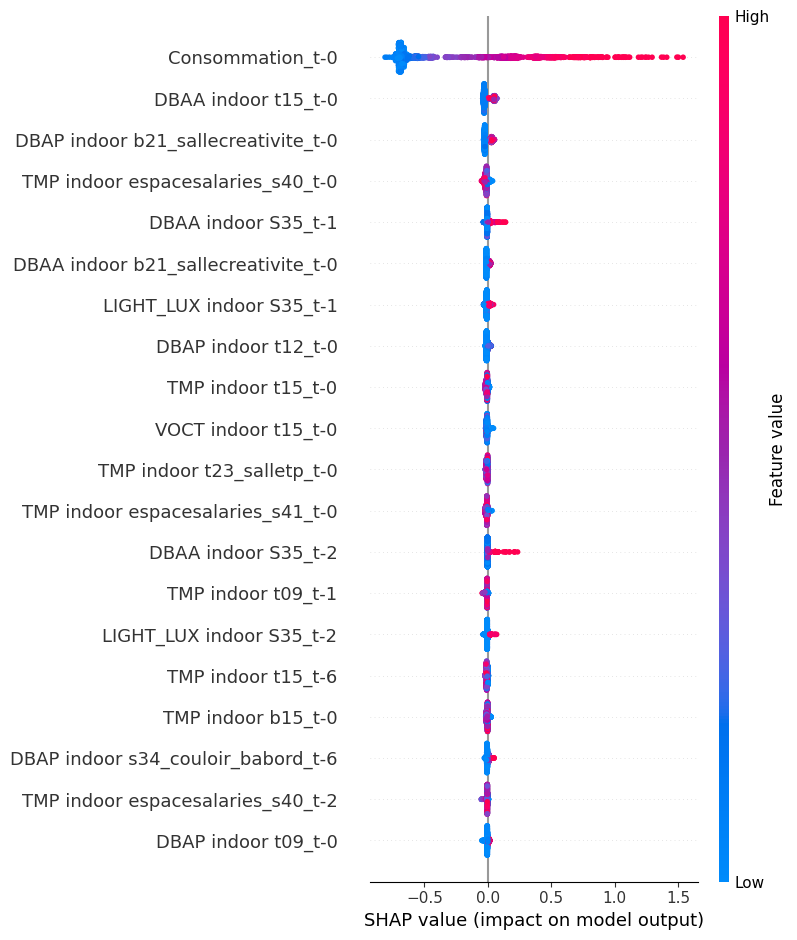

In [ ]:
shap.summary_plot(shap_values, features=X_test, feature_names=flat_feature_names, max_display=20, show=True)
